# ge

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# df = pd.read_csv("C:\\Users\\Admin\\Downloads\\titanic.csv")
df = pd.read_csv(r"C:\Users\Admin\Downloads\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [7]:
df.drop(columns = ['Cabin'], inplace = True)

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

**Creating age groups**

In [14]:
bins = [0, 12, 20, 40, 60 ,80]
labels = ['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels = labels)

**Create Family size Feature**

In [15]:
df['FamilySize'] = df['SibSp']+ df['Parch']

#**Analysis Using groupBy**

Survival rate bu Age Group

In [16]:
age_survival = df.groupby('AgeGroup')['Survived'].mean()
age_survival

C:\Users\Admin\AppData\Local\Temp\ipykernel_15324\2602624233.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Child         0.579710
Teen          0.381818
Adult         0.364769
Middle Age    0.390625
Senior        0.227273
Name: Survived, dtype: float64

In [18]:
embark_survival = df.groupby('Embarked')['Survived'].mean()
embark_survival

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

**Survival Rate by Family size**

In [19]:
family_survival = df.groupby('FamilySize')['Survived'].mean()
family_survival

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

**Visualizations**

Age distribution (Histogram)

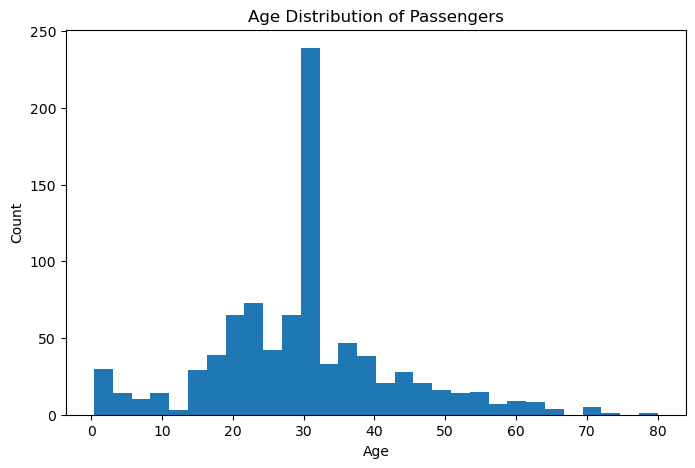

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

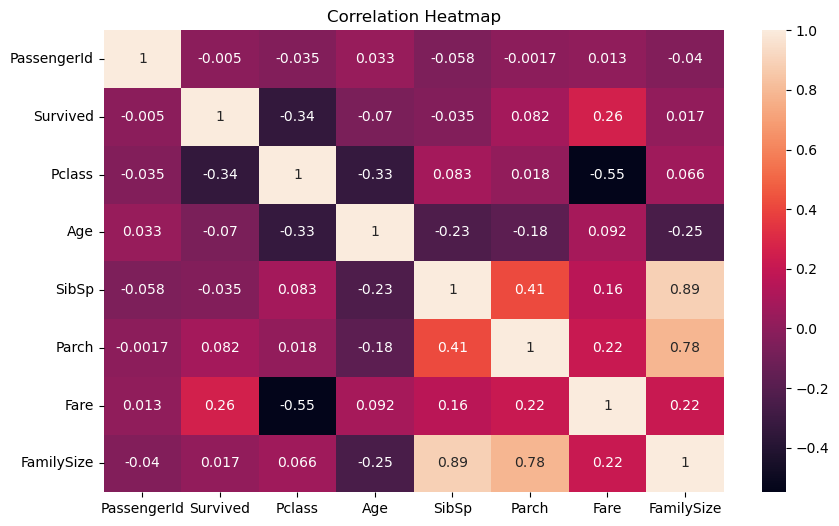

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

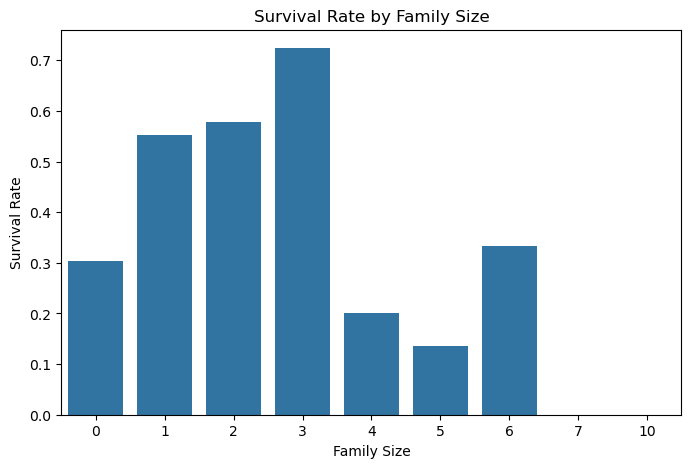

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x=family_survival.index, y=family_survival.values)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

**Key Insights (Storytelling Section)**

Children and women passengers had a higher survival rate.
Passengers traveling with small to medium-sized families were safer and had better survival chances.
First-class passengers had a higher probability of survival compared to other classes.
The port of embarkation influenced survival outcomes.

**Conclusion**

Through this Mini EDA task:

We learned how to effectively clean the dataset by handling missing values and removing irrelevant columns.
Meaningful insights were derived using groupby operations.
Data patterns and relationships were clearly explained using appropriate visualizations.